In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/auto-mpg.csv")
df["car name"].nunique()







305

In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
df.shape

(398, 9)

In [ ]:
df.describe(include='all')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,398.000000,398.000000,398.000000,398,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,94,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,150,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,NaN,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,NaN,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,NaN,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,NaN,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,NaN,3608.000000,17.175000,79.000000,2.000000,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


<Axes: xlabel='cylinders', ylabel='count'>

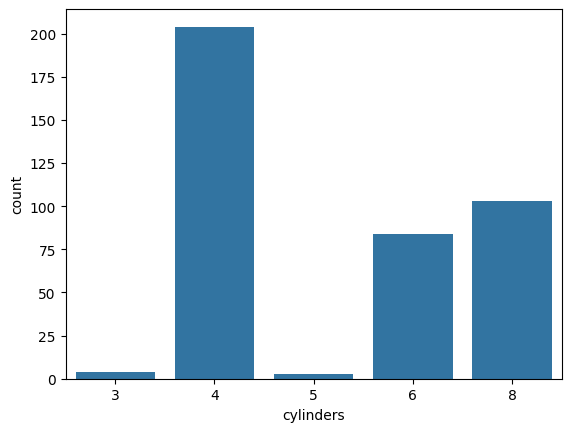

In [ ]:
sns.countplot(x="cylinders", data=df)

array([[<Axes: title={'center': 'mpg'}>,
        <Axes: title={'center': 'cylinders'}>,
        <Axes: title={'center': 'displacement'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'acceleration'}>,
        <Axes: title={'center': 'model year'}>],
       [<Axes: title={'center': 'origin'}>, <Axes: >, <Axes: >]],
      dtype=object)

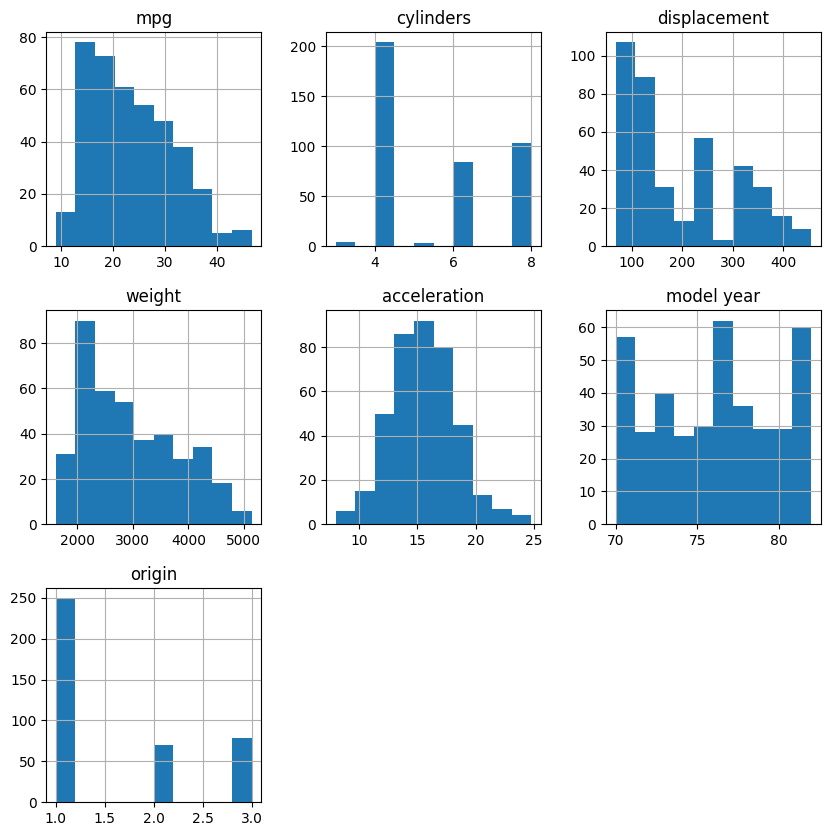

In [ ]:
df.hist(figsize=(10,10))

<Axes: xlabel='displacement', ylabel='count'>

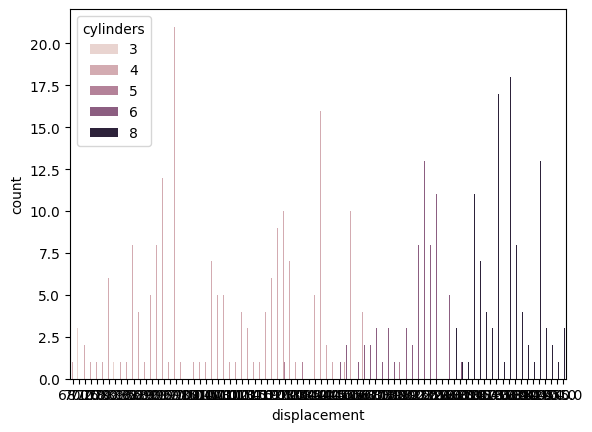

In [ ]:
df.isnull().sum()

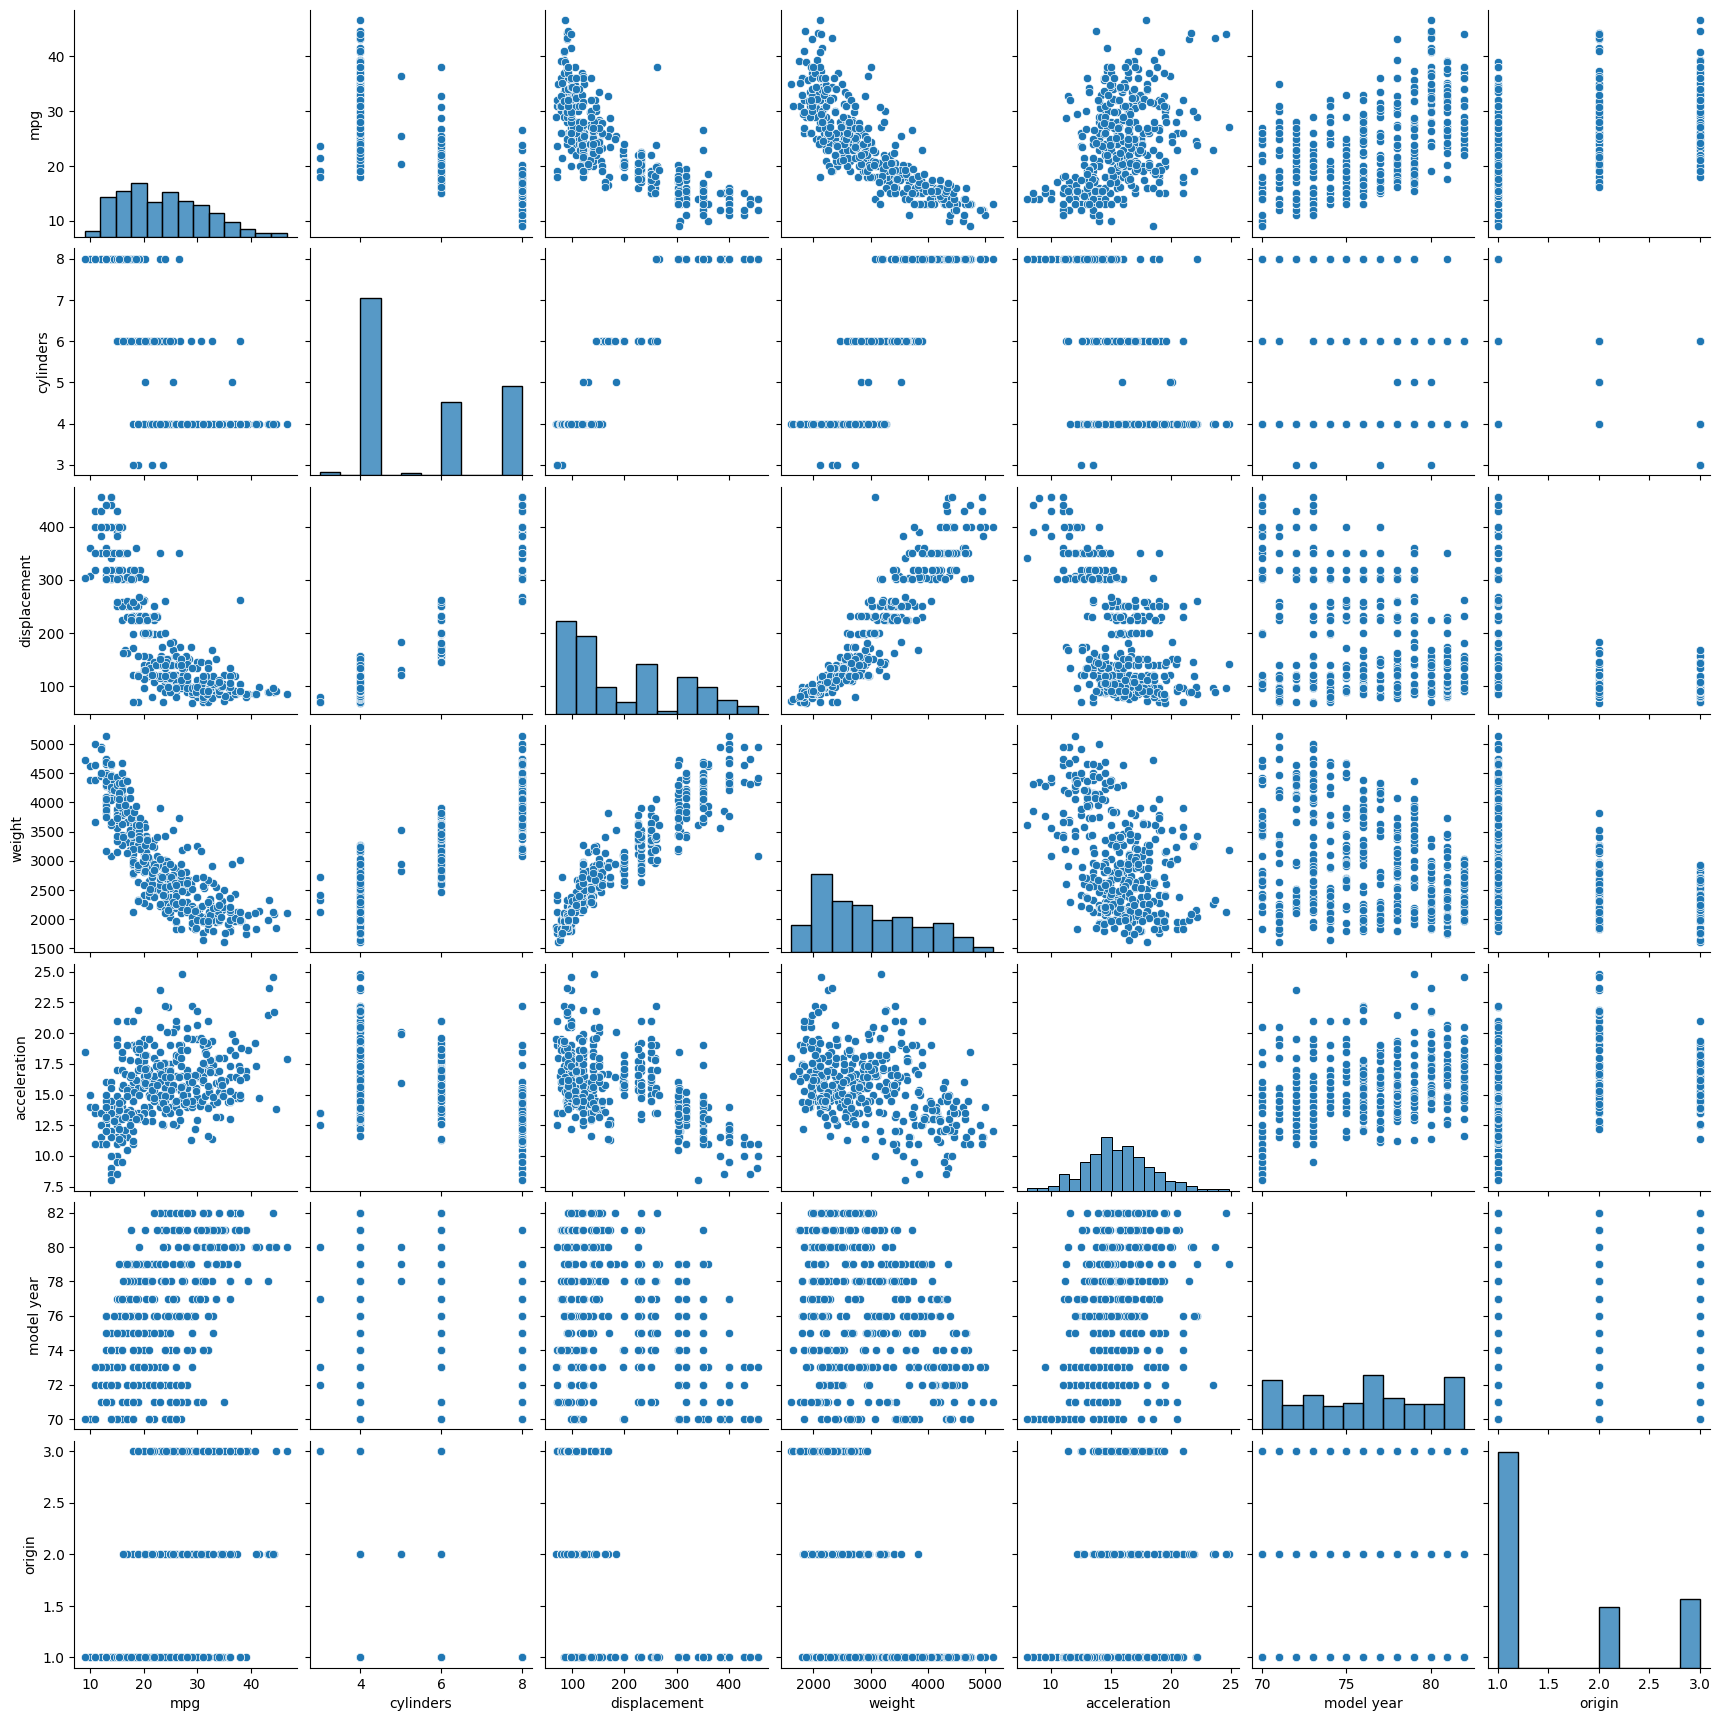

In [ ]:
sns.pairplot(data=df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [ ]:
df.sample(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
178,23.0,4,120.0,88,2957,17.0,75,2,peugeot 504
23,26.0,4,121.0,113,2234,12.5,70,2,bmw 2002


In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


### Identifying Insignificant Columns

Based on the `df.info()` and `df.describe(include='all')` outputs, some columns might be considered insignificant for direct numerical analysis:

1.  **`car name`**: This column has 305 unique values out of 398 entries. It's an object type and acts as an identifier, typically not useful for numerical prediction models directly. It's often dropped or used only for display purposes.
2.  **`horsepower`**: This column is of `object` type, which indicates it's not purely numerical. The `df.describe(include='all')` output shows it contains '?' characters, which need to be handled before it can be used as a numerical feature. In its current state, it's not directly usable for numerical analysis.

In [ ]:
# Drop the 'car name' column as it is an identifier and unlikely to be useful for modeling
#df = df.drop('car name', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 25.0+ KB


### Handling 'horsepower' column

The 'horsepower' column is of object type because it contains '?' characters. We need to replace these with NaN (Not a Number) and then convert the column to a numeric data type. We can then check for and handle these NaN values.

In [ ]:
# Replace '?' with NaN in 'horsepower' column
df['horsepower'] = df['horsepower'].replace('?', np.nan)

# Convert 'horsepower' to numeric type
#df_clea['horsepower'] = pd.to_numeric(df_cleaned['horsepower'])

# Check for missing values after conversion
#print("Missing values in 'horsepower' after conversion:")
#display(df_cleaned.isnull().sum())

In [ ]:
df.sample(100)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
180,25.0,4,121.0,115,2671,13.5,75,2
386,25.0,6,181.0,110,2945,16.4,82,1
339,26.6,4,151.0,84,2635,16.4,81,1
361,25.4,6,168.0,116,2900,12.6,81,3
143,26.0,4,97.0,78,2300,14.5,74,2
...,...,...,...,...,...,...,...,...
240,30.5,4,97.0,78,2190,14.1,77,2
150,26.0,4,108.0,93,2391,15.5,74,3
24,21.0,6,199.0,90,2648,15.0,70,1
83,28.0,4,98.0,80,2164,15.0,72,1


In [ ]:
df['horsepower'] = pd.to_numeric(df['horsepower'])


In [ ]:
df["horsepower"].median()

93.5

In [ ]:
median_horsepower=df["horsepower"].median()
median_horsepower

93.5

In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0


In [ ]:
df["horsepower"]=df["horsepower"].replace(np.nan,median_horsepower)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


In [ ]:
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/loan_prediction.csv")
df.head()
Y=df["Loan_Status"]
X=df.drop(["Loan_Status"],axis=1)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3)

In [ ]:
from sklearn.linear_model import LogisticRegression
model_lr=LogisticRegression()
model_lr.fit(X_train,Y_train)

ValueError: could not convert string to float: 'LP002961'